# Lab 1: The six components, by hand

**DSAN-6600 Deep Learning · Fall 2026**

**Due:** Wednesday Sep 2, 11:59 PM ET · **Target time:** about 60–75 minutes

---

## What this lab is for

Week 1 argued that every model in this course is the same six components:
data, a parametric model, residuals, a loss, splits, and an optimizer. This lab
has you build all six with nothing but NumPy, so that when PyTorch shows up in
Week 3 you already know what it is doing for you.

No PyTorch. No neural networks yet. Just the machinery underneath them.

## How this lab is graded

Read this part carefully, because it is different from what you may be used to.

- **The notebook is graded for completion, not for correctness.** Submit it,
  with all cells run and outputs visible, and you get the points. We are not
  grading your code style, and we are not grading whether your numbers are right.
- **You may work together.** Talk it through, compare results, help each other
  debug. Everyone runs the same data, so your numbers *should* match your
  neighbor's. That is by design.
- **The understanding is assessed on the Week 2 quiz.** Roughly a third of the
  quiz asks you to explain **what this lab demonstrated and why**. Those
  questions are hard to answer well if you did not run the lab and look at the
  output yourself.
- **Solutions are posted after the deadline**, so you can check yourself and
  clear up anything that did not land.

So the incentive is simple: it does not matter much how you get the notebook
done. It matters a great deal that you understand what it showed you.

## Using AI on this lab

Allowed and expected, with disclosure; there is a cell for that at the end. But
note what the design does to the calculus. An agent can write this code for you
in a minute, and you will still be sitting the quiz on Thursday by yourself, with
no notes. Use the agent to move faster, then spend the time you saved actually
reading your own plots.

## Step 0: Setup

Everyone in the class runs the **same seed**, so we all see the same data and the
same numbers. That means the lab has right answers, you can compare with a
classmate, and the posted solution will match what you got.

Just run this cell.

In [ ]:
SEED = 6600      # the whole class uses this, so everyone sees the same data

# ---------------------------------------------------------------------------
import sys

import numpy as np
import matplotlib.pyplot as plt

print(f"python  {sys.version.split()[0]}")
print(f"numpy   {np.__version__}")
print(f"seed    {SEED}")

---

# Part 1 · Component 1: Data

We generate a regression dataset. The underlying truth is a cubic function of one
input, plus noise. You do not get to see the true coefficients until the end.

The signal is rescaled to unit variance before the noise is added, so the
difficulty of the problem is a known, fixed quantity rather than an accident of
the random draw.

In [ ]:
rng = np.random.default_rng(SEED)

# ---- the true (hidden) function: a cubic
w_raw = rng.uniform(-2.0, 2.0, size=4)

N = 400
x_all = rng.uniform(-1.0, 1.0, N)

# Rescaling the signal to unit variance makes the noise setting below an
# absolute one, so we know exactly how hard the problem is.
signal_raw = (w_raw[0] + w_raw[1] * x_all
              + w_raw[2] * x_all**2 + w_raw[3] * x_all**3)
w_true = w_raw / signal_raw.std()
signal = signal_raw / signal_raw.std()

def true_f(x):
    return w_true[0] + w_true[1] * x + w_true[2] * x**2 + w_true[3] * x**3

NOISE_SD = 0.25
y_all = signal + rng.normal(0.0, NOISE_SD, N)

print(f"generated {N} points")
print(f"signal variance   {signal.var():.4f}   (scaled to 1 by construction)")
print(f"noise sd          {NOISE_SD}")
print(f"noise variance    {NOISE_SD**2:.4f}   <- no model can do better than this")

## Component 5, early: the splits

We do this **now**, before looking at anything, because that is the only way it
protects you. Split into 60% train / 20% validation / 20% test.

Fill in the TODO: shuffle the indices and slice them into three groups.

In [21]:
# Shuffle once, then slice. Never split on sorted data.
idx = rng.permutation(N)

n_train = int(0.60 * N)
n_val   = int(0.20 * N)

# TODO: slice `idx` into three index arrays.
#   train_idx = the first n_train entries
#   val_idx   = the next n_val entries
#   test_idx  = everything left over
train_idx = idx[:n_train]
val_idx   = idx[n_train:n_train+n_val]
test_idx  = idx[n_train+n_val:]

if train_idx is None or val_idx is None or test_idx is None:
    raise NotImplementedError("Fill in the three index slices above.")

x_tr, y_tr = x_all[train_idx], y_all[train_idx]
x_va, y_va = x_all[val_idx],   y_all[val_idx]
x_te, y_te = x_all[test_idx],  y_all[test_idx]

print(f"train {len(x_tr)}   val {len(x_va)}   test {len(x_te)}")
assert len(x_tr) + len(x_va) + len(x_te) == N, "splits must cover every point"

train 240   val 80   test 80


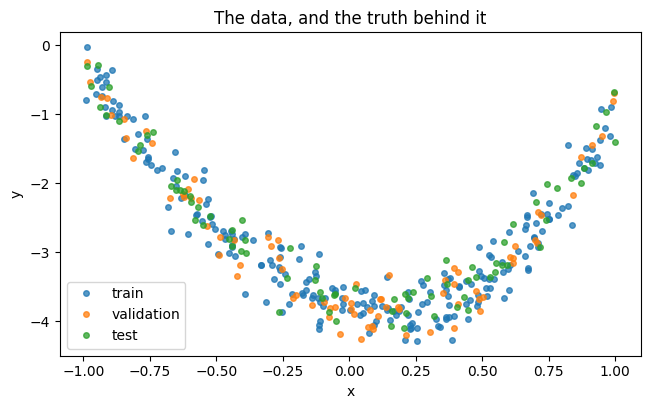

In [22]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(x_tr, y_tr, "o", ms=4, alpha=0.75, label="train")
ax.plot(x_va, y_va, "o", ms=4, alpha=0.75, label="validation")
ax.plot(x_te, y_te, "o", ms=4, alpha=0.75, label="test")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("The data, and the truth behind it")
ax.legend()
plt.show()

**Q1. You have a train set and a test set. Why do you also need a validation
set? What specifically goes wrong if you tune on the test set instead?**

*Your answer:*

The validation set is used to tune hyperparameters and evaluate model performance during training (e.g., selecting the best checkpoint at each epoch) without touching the test set.

If we tune directly on the test set, information leaks from the test set into the model training process. This leads to overfitting on the test set, giving us an unrealistically optimistic performance metric.

---

# Part 2 · Components 2, 3, 4: model, residuals, loss

Start with the simplest parametric model there is, a straight line with two
parameters:

$$\hat{y} = w_0 + w_1 x$$

The truth is a cubic, so a line **cannot** fit it well. That is on purpose; it
is the underfitting end of the story we finish in Part 4.

Fill in the two TODOs: the model, and mean squared error.

In [28]:
def model_linear(x, w):
    """w is [w0, w1]. Return predictions for x."""
    # TODO: return the straight-line prediction
    return w[0] +w[1] * x

def mse(y, y_hat):
    """Mean squared error: the average squared residual."""
    # TODO: residuals are (y - y_hat). Square them, take the mean.
    return np.mean((y - y_hat)**2)

def mae(y, y_hat):
    """Mean absolute error."""
    return np.mean(np.abs(y - y_hat))

# sanity check with a deliberately bad guess
w_guess = np.array([0.0, 0.0])
w_guess[0]
_probe = model_linear(x_tr, w_guess)
if _probe is None or mse(y_tr, _probe) is None:
    raise NotImplementedError("Implement model_linear() and mse() above.")

print(f"all-zero model:  MSE = {mse(y_tr, model_linear(x_tr, w_guess)):.4f}")
print(f"all-zero model:  MAE = {mae(y_tr, model_linear(x_tr, w_guess)):.4f}")

all-zero model:  MSE = 8.9870
all-zero model:  MAE = 2.8186


**Q2. MSE and MAE both score the same predictions, and above they give
different numbers. Which one is more sensitive to a single badly wrong point,
and why does the formula make that happen?**

*Your answer:*

The MSE score is more sensitive than MAE score, because the Square operation will penalize the Error scale of a single sample.

---

# Part 3 · Component 6: The optimizer

No closed-form solution here; we descend, exactly as in the Week 1 demo. The
gradient is estimated numerically so you can see that nothing magic is
happening: nudge a parameter, see whether the loss went down.

Fill in the TODO: the gradient descent update.

In [33]:
def numeric_grad(loss_fn, w, h=1e-6):
    """Central-difference gradient of loss_fn at w."""
    g = np.zeros_like(w, dtype=float)
    for i in range(len(w)):
        up, dn = w.astype(float).copy(), w.astype(float).copy()
        up[i] += h
        dn[i] -= h
        g[i] = (loss_fn(up) - loss_fn(dn)) / (2 * h)
    return g

def train_loss(w):
    return mse(y_tr, model_linear(x_tr, w))

def val_loss(w):
    return mse(y_va, model_linear(x_va, w))

w = np.array([0.0, 0.0])
LR, STEPS = 0.1, 300
hist = []

for step in range(STEPS):
    g = numeric_grad(train_loss, w)
    # TODO: one gradient descent step. Move w downhill, scaled by LR.
    #       Remember the gradient points UPhill.
    w = w - LR * g
    hist.append((train_loss(w), val_loss(w)))

hist = np.array(hist)
w_linear = w.copy()

if hist[-1, 0] >= hist[0, 0]:
    raise NotImplementedError(
        "The training loss did not go down, so the update step is still a "
        "no-op. Implement the gradient descent step above."
    )

print(f"final w0 = {w_linear[0]:.4f}")
print(f"final w1 = {w_linear[1]:.4f}")
print(f"train MSE = {hist[-1, 0]:.4f}")
print(f"val   MSE = {hist[-1, 1]:.4f}")

final w0 = -2.8012
final w1 = -0.6513
train MSE = 0.9082
val   MSE = 1.0163


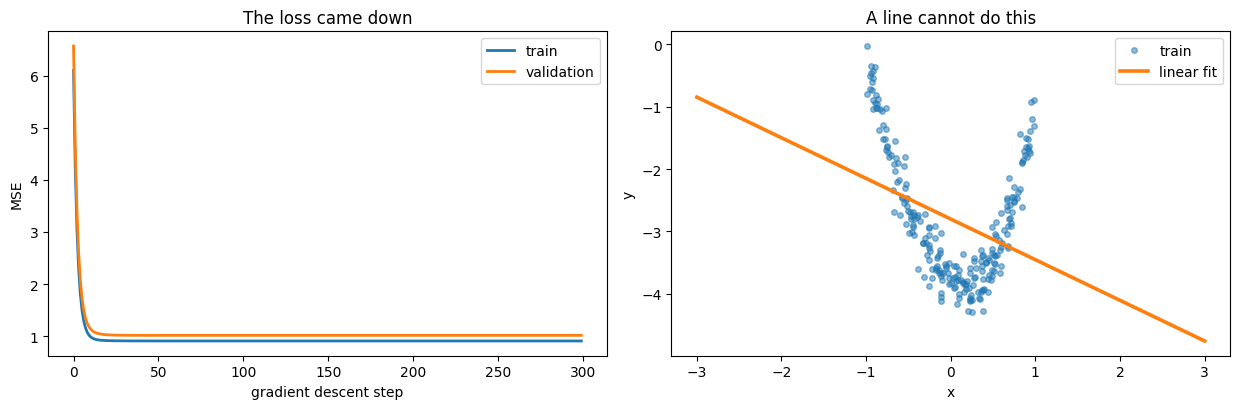

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

axes[0].plot(hist[:, 0], lw=2, label="train")
axes[0].plot(hist[:, 1], lw=2, label="validation")
axes[0].set_xlabel("gradient descent step"); axes[0].set_ylabel("MSE")
axes[0].set_title("The loss came down")
axes[0].legend()

grid = np.linspace(-3, 3, 200)
axes[1].plot(x_tr, y_tr, "o", ms=4, alpha=0.5, label="train")
axes[1].plot(grid, model_linear(grid, w_linear), lw=2.6, label="linear fit")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_title("A line cannot do this")
axes[1].legend()

plt.tight_layout()
plt.show()

## The learning rate

Run the same descent at three learning rates and watch what changes.

lr = 0.001  final train MSE = 3.3710
lr = 0.1    final train MSE = 0.9082
lr = 1.02   DIVERGED at step 142


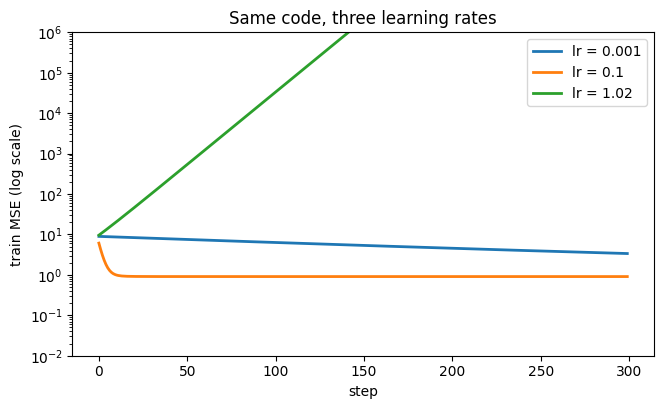

In [36]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
BLOWUP = 1e6

for lr in (0.001, 0.1, 1.02):
    ww, curve = np.array([0.0, 0.0]), []
    diverged_at = None
    for step in range(STEPS):
        ww = ww - lr * numeric_grad(train_loss, ww)
        L = train_loss(ww)
        curve.append(L)
        if not np.isfinite(L) or L > BLOWUP:
            diverged_at = step
            break

    ax.plot(curve, lw=2, label=f"lr = {lr}")
    if diverged_at is None:
        print(f"lr = {lr:<6} final train MSE = {curve[-1]:.4f}")
    else:
        print(f"lr = {lr:<6} DIVERGED at step {diverged_at}")

ax.set_yscale("log")
ax.set_ylim(1e-2, BLOWUP)          # so the divergent run runs off the top
ax.set_xlabel("step"); ax.set_ylabel("train MSE (log scale)")
ax.set_title("Same code, three learning rates")
ax.legend()
plt.show()

**Q3. Describe what each of the three learning rates did to the loss curve. What
is the failure mode at the low end, and what is it at the high end?**

*Your answer:*

Lr = 0.001: The loss decreases extremely slowly, when the training arrive the 300 steps, it looks like not convergence.

Lr = 0.1: The loss drops rapidly within the first ~20 steps and smoothly converges to a low value, it's best of three lR.

Lr = 1.02: The loss increases exponentially right from the start, causing the model to diverge.

At the low end: The failure mode is extremely slow convergence. Due to slowly gradient updates, the loss fails to reach the global minimum within the given training steps.

At the high end: The failure mode is divergence (the learning rate is set too high). Beyond a certain step, the loss explodes rather than decreasing, preventing the model from training successfully.

---

# Part 4 · Component 5 doing real work: finding the right capacity

Now give the model more parameters and watch the validation set earn its keep.

A degree-$d$ polynomial has $d+1$ parameters:

$$\hat{y} = w_0 + w_1 x + w_2 x^2 + \dots + w_d x^d$$

Degree 1 is the line from Part 3, which underfits. A very high degree will chase
the noise. Somewhere in between is the capacity your data actually supports, and
**only the validation set can tell you where.**

We solve each fit directly with least squares rather than descending, because
here we care about the capacity story, not the optimizer.

## One deliberate change: a starved training set

Overfitting is not a property of a model by itself. It is the **ratio of
capacity to data**. With all 240 training points, even a degree-20 polynomial
behaves itself. With 30 points it comes apart completely, and that is what makes
the effect visible in a single plot.

So for this part only, we fit on the **first 30 training points** and keep the
full validation set. A degree-20 fit then has 21 parameters for 30 points, which
is roughly where the trouble starts. Remember this ratio when we reach networks
with millions of parameters: the reason those work at all is that the other side
of the fraction got very large too.

Fill in the TODO: record train and validation MSE for each degree.

In [40]:
N_STARVED = 30
x_small, y_small = x_tr[:N_STARVED], y_tr[:N_STARVED]
print(f"fitting on {len(x_small)} points, validating on {len(x_va)}")

DEGREES = range(1, 21)
rows = []

for d in DEGREES:
    # Vandermonde design matrix, then least squares. This is the analytic
    # solution mentioned in lecture, standing in for the optimizer.
    Xs = np.vander(x_small, d + 1, increasing=True)
    coef, *_ = np.linalg.lstsq(Xs, y_small, rcond=None)

    pred_tr = Xs @ coef
    pred_va = np.vander(x_va, d + 1, increasing=True) @ coef

    # TODO: append (d, train MSE, validation MSE) to `rows`
    #       use y_small for the train side, y_va for the validation side
    rows.append([d, mse(y_small, pred_tr), mse(y_va, pred_va)])


if len(rows) == 0:
    raise NotImplementedError("Append (degree, train MSE, val MSE) to `rows`.")

rows = np.array(rows)
best_i = int(np.argmin(rows[:, 2]))
best_degree = int(rows[best_i, 0])
best_val = rows[best_i, 2]

print(f"{'degree':>7}{'train MSE':>13}{'val MSE':>12}")
for d, tr, va in rows:
    mark = "   <-- best" if int(d) == best_degree else ""
    print(f"{int(d):>7}{tr:>13.4f}{va:>12.4f}{mark}")

print(f"\nbest degree by validation MSE: {best_degree}  (val MSE {best_val:.4f})")
print(f"val MSE at degree 20:          {rows[-1, 2]:.4g}")
print(f"that is {rows[-1, 2] / best_val:,.0f}x worse than the best degree")

fitting on 30 points, validating on 80
 degree    train MSE     val MSE
      1       0.8794      1.0142
      2       0.0989      0.0714
      3       0.0826      0.0567   <-- best
      4       0.0808      0.0650
      5       0.0728      0.0775
      6       0.0728      0.0781
      7       0.0724      0.0968
      8       0.0684      0.2436
      9       0.0677      0.1470
     10       0.0624      0.8617
     11       0.0619      0.1916
     12       0.0557     15.8065
     13       0.0527      3.6448
     14       0.0522     22.3896
     15       0.0521     21.8849
     16       0.0514    434.6070
     17       0.0495   3199.0035
     18       0.0484  24377.1830
     19       0.0483  46433.9868
     20       0.02657451997.4743

best degree by validation MSE: 3  (val MSE 0.0567)
val MSE at degree 20:          7.452e+06
that is 131,465,623x worse than the best degree


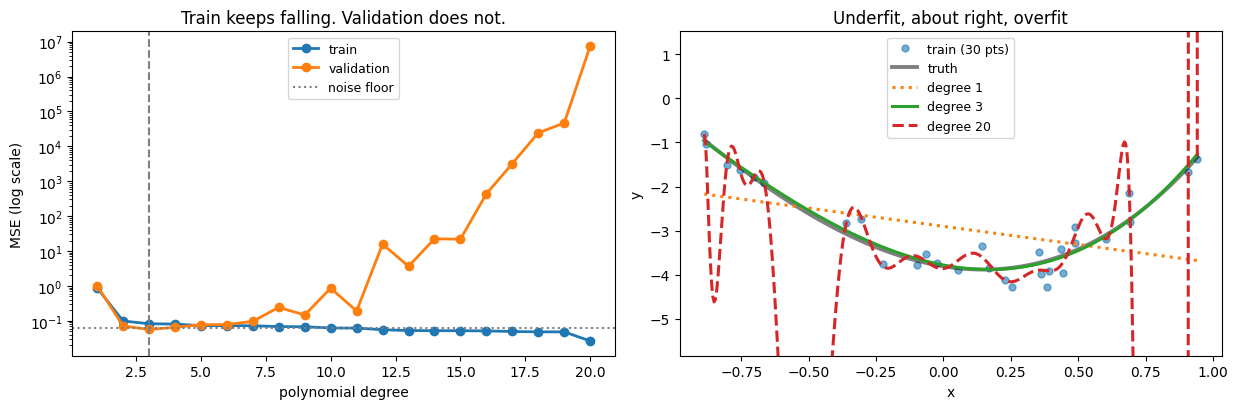

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

axes[0].plot(rows[:, 0], rows[:, 1], "o-", lw=2, label="train")
axes[0].plot(rows[:, 0], rows[:, 2], "o-", lw=2, label="validation")
axes[0].axhline(NOISE_SD**2, ls=":", color="gray", label="noise floor")
axes[0].axvline(best_degree, ls="--", color="gray")
axes[0].set_yscale("log")
axes[0].set_xlabel("polynomial degree"); axes[0].set_ylabel("MSE (log scale)")
axes[0].set_title("Train keeps falling. Validation does not.")
axes[0].legend(fontsize=9)

grid = np.linspace(x_small.min(), x_small.max(), 400)
axes[1].plot(x_small, y_small, "o", ms=5, alpha=0.6, label="train (30 pts)")
axes[1].plot(grid, true_f(grid), color="black", lw=2.8, alpha=0.5, label="truth")
for d, style in ((1, ":"), (best_degree, "-"), (20, "--")):
    Xg = np.vander(grid, d + 1, increasing=True)
    Xs = np.vander(x_small, d + 1, increasing=True)
    cf, *_ = np.linalg.lstsq(Xs, y_small, rcond=None)
    axes[1].plot(grid, Xg @ cf, style, lw=2.2, label=f"degree {d}")
# clamp: the degree-15 fit leaves the plot entirely, which is the point
pad = 1.5 * y_all.std()
axes[1].set_ylim(y_all.min() - pad, y_all.max() + pad)
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_title("Underfit, about right, overfit")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Q4. Look at the left plot. Training MSE falls essentially forever as degree
grows, but validation MSE turns around. Explain why training loss alone can
never tell you the right degree.**

*Your answer:*

Training loss only measures how well a model fits the training data, not how well it generalizes to unseen data (like real world data).

**Q5. The true function behind your data is a cubic (degree 3). Did validation
pick exactly 3? If not, what does that tell you about picking capacity from a
finite, noisy sample?**

*Your answer:*



---

# Part 5 · A different problem type: classification

Same six components, different loss. Two input features, one binary label, and a
model that is a **logistic regression**, which Week 1 argued is already a
one-neuron network:

$$\hat{p} = \sigma(w_0 + w_1 x_1 + w_2 x_2), \qquad \sigma(z) = \frac{1}{1 + e^{-z}}$$

The labels are generated *probabilistically*, so even a perfect model cannot get
100% accuracy. That matters for the last question.

Fill in the TODOs: the sigmoid and binary cross-entropy.

In [42]:
# ---- the classification dataset
Xc = rng.normal(size=(400, 2))
w_true_c = np.concatenate([rng.uniform(-1.2, 1.2, 1),      # intercept
                           rng.uniform(-2.5, 2.5, 2)])     # slopes
logits_true = w_true_c[0] + Xc @ w_true_c[1:]
p_true = 1.0 / (1.0 + np.exp(-logits_true))
yc = rng.binomial(1, p_true).astype(float)

ci = rng.permutation(len(yc))
c_tr, c_va = ci[:280], ci[280:]
Xc_tr, yc_tr = Xc[c_tr], yc[c_tr]
Xc_va, yc_va = Xc[c_va], yc[c_va]

print(f"class balance (train): {yc_tr.mean():.3f}")
print(f"train {len(yc_tr)}   val {len(yc_va)}")

class balance (train): 0.432
train 280   val 120


In [ ]:
def sigmoid(z):
    # TODO: the logistic function
    return 1 / (1 + np.exp(-z))

def bce(y, p, eps=1e-12):
    """Binary cross-entropy. eps keeps log() away from zero."""
    p = np.clip(p, eps, 1 - eps)
    # TODO: -mean( y*log(p) + (1-y)*log(1-p) )
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def predict_proba(X, w):
    return sigmoid(w[0] + X @ w[1:])

# quick check: a model that always says 0.5 should score about log(2) = 0.693
if sigmoid(0.0) is None or bce(yc_tr, np.full(len(yc_tr), 0.5)) is None:
    raise NotImplementedError("Implement sigmoid() and bce() above.")

print(f"BCE of a 50/50 model: {bce(yc_tr, np.full(len(yc_tr), 0.5)):.4f}")

In [ ]:
def c_train_loss(w):
    return bce(yc_tr, predict_proba(Xc_tr, w))

wc = np.zeros(3)
c_hist = []
for _ in range(600):
    wc = wc - 0.5 * numeric_grad(c_train_loss, wc)
    c_hist.append((c_train_loss(wc), bce(yc_va, predict_proba(Xc_va, wc))))

c_hist = np.array(c_hist)
p_va = predict_proba(Xc_va, wc)

acc_50 = np.mean((p_va >= 0.50) == yc_va)
acc_70 = np.mean((p_va >= 0.70) == yc_va)

# The score to beat before you are allowed to be pleased: always guess the
# most common class.
baseline_acc = max(yc_va.mean(), 1 - yc_va.mean())

print(f"final val BCE            {c_hist[-1, 1]:.4f}")
print(f"val accuracy @ 0.50      {acc_50:.4f}")
print(f"val accuracy @ 0.70      {acc_70:.4f}")
print(f"majority-class baseline  {baseline_acc:.4f}   <- beat this or you have nothing")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

axes[0].plot(c_hist[:, 0], lw=2, label="train BCE")
axes[0].plot(c_hist[:, 1], lw=2, label="val BCE")
axes[0].set_xlabel("step"); axes[0].set_ylabel("binary cross-entropy")
axes[0].set_title("Training the classifier")
axes[0].legend()

for cls, marker in ((0, "o"), (1, "^")):
    m = yc_va == cls
    axes[1].plot(Xc_va[m, 0], Xc_va[m, 1], marker, ms=5, alpha=0.75,
                 label=f"class {cls}")
gx = np.linspace(Xc[:, 0].min(), Xc[:, 0].max(), 200)
# decision boundary: w0 + w1*x1 + w2*x2 = 0
if abs(wc[2]) > 1e-9:
    axes[1].plot(gx, -(wc[0] + wc[1] * gx) / wc[2], "k--", lw=2,
                 label="decision boundary")
axes[1].set_xlim(Xc[:, 0].min(), Xc[:, 0].max())
axes[1].set_ylim(Xc[:, 1].min(), Xc[:, 1].max())
axes[1].set_xlabel("$x_1$"); axes[1].set_ylabel("$x_2$")
axes[1].set_title("A linear boundary, from a one-neuron network")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Q6. Your accuracy changed when the threshold moved from 0.50 to 0.70, but the
model did not change at all. Explain the difference between the loss the
optimizer minimized and the accuracy you reported.**

*Your answer:*

**Q7. Compare your accuracy to the majority-class baseline printed above. How
much did your model actually add? If someone showed you an accuracy number with
no baseline next to it, what would you ask them for?**

*Your answer:*

**Q8. The labels here were drawn randomly from the true probabilities, so some
points are genuinely unpredictable. What does that mean for how much accuracy
is achievable, and how would you know you had hit that limit?**

*Your answer:*

---

# Part 6 · Spending the test set

You have made two real choices using validation: a learning rate, and a
polynomial degree. Now, **once**, look at the test set.

In [ ]:
Xs_best = np.vander(x_small, best_degree + 1, increasing=True)
coef_best, *_ = np.linalg.lstsq(Xs_best, y_small, rcond=None)
test_mse = mse(y_te, np.vander(x_te, best_degree + 1, increasing=True) @ coef_best)

print(f"chosen degree     {best_degree}")
print(f"validation MSE    {best_val:.4f}")
print(f"test MSE          {test_mse:.4f}")
print(f"noise floor       {NOISE_SD**2:.4f}   (irreducible: the variance we added)")

**Q9. You picked the degree by looking at validation, so on average validation
flatters the model slightly and test is the more honest number. Report both of
yours. Did test come out worse, as that reasoning predicts, or better? Either
happens on a sample of 80; explain why.**

*Your answer:*

**Q10. Your test MSE should land near the noise floor. What would you conclude
if it were far below the floor instead?**

*Your answer:*

---

# Part 7 · What this lab showed

**This is the part that gets assessed.** Roughly a third of Quiz 1 asks you to
explain the things below. Nothing to memorize and no numbers to transcribe: the
quiz asks *why*, not *what was your value*.

Scroll back through your own plots and make sure you can say, in a sentence each:

1. **Why you split the data before looking at it.** What goes wrong if you
   evaluate a model on the rows it learned from.
2. **Why MSE and MAE disagree about outliers.** Which one you would pick if a few
   extreme values were genuine, and which if they were sensor glitches.
3. **What the learning rate controls, and both ways it fails.** You saw one rate
   crawl and one diverge. Why does too large a step make the loss go *up*?
4. **What training loss did versus validation loss as the degree rose.** Training
   MSE fell all the way to degree 20 while validation exploded. Why can training
   loss never tell you the right degree?
5. **Why the accuracy changed when you moved the threshold from 0.50 to 0.70,
   even though the model did not change.** And why BCE, not accuracy, is what the
   optimizer minimizes.
6. **Why your classifier's accuracy has to be compared to the majority-class
   baseline** before it means anything.
7. **Why no model could push test MSE much below the noise floor.** What the
   floor is, and why beating it slightly on 80 points is not a real win.

If you can answer those seven, you are ready for the quiz.

---

# Part 8 · AI disclosure

Required if you used any generative AI on this lab. Name the tool, say where you
used it, and say what for. "None" is a perfectly good answer.

*Tool(s):*

*Where:*

*What for:*

---

# Submitting

1. **Restart the kernel and Run All.** Confirm it runs top to bottom.
2. Check that every plot and every printed block is visible.
3. Render to **HTML or PDF** with resources embedded.
4. Submit the rendered file on Canvas. Due **Wed Sep 2, 11:59 PM ET**.

The notebook is graded for completion, so this is mostly a formality. The
understanding is graded on Thursday, closed-book, with no notes. Part 7 is your
study guide for that.